In [1]:
from pathlib import Path
import pyvista as pv


path = Path("/Users/arstanbekokenov/Projects/Finitewave-Meshtools/data/11/11-350um.vtk")
heart_mesh = pv.read(path)

In [2]:
elem_tag = heart_mesh.cell_data["elemTag"]
lv_mesh = heart_mesh.extract_cells(elem_tag == 1)
# remove the points that are not part of the left ventricle mesh
lv_mesh = lv_mesh.clean()

In [3]:
cells = lv_mesh.cells.reshape(-1, 5)[:, 1:]
points = lv_mesh.points

In [24]:
cells.max(), points.shape, points.min(axis=0), points.max(axis=0)

(np.int64(5095988),
 (5095989, 3),
 pyvista_ndarray([ -8.122253,  58.3715  , 113.039955], dtype=float32),
 pyvista_ndarray([ 95.506836, 160.8909  , 195.99904 ], dtype=float32))

In [22]:
np.save("/Users/arstanbekokenov/Projects/Finitewave/examples/data/lv_mesh/points.npy", points.astype(np.float32))
np.save("/Users/arstanbekokenov/Projects/Finitewave/examples/data/lv_mesh/cells.npy", cells.astype(np.int32))

In [4]:
import finitewave as fw

tissue_lv = fw.CardiacTissueElements(points, cells, fw.ElementType.TETRA)

diffusion_model = fw.DiffusionModelElements()
diffusion_model.reference_element = fw.LinearTetrahedralElement()
K_lv, M = diffusion_model.compute_weights(tissue_lv)

In [5]:
# create a tissue of size 400x400 with cardiomycytes:
nx, ny, nz = 400, 200, 40
size_x = (0, 50)
size_y = (0, 25)
size_z = (0, 5)

coords, elems = fw.build_tetrahedral_slab(nx, ny, nz, size_x, size_y, size_z)

# create cardiac tissue object:
tissue_slab = fw.CardiacTissueElements(coords, elems, fw.ElementType.TETRA)
diffusion_model = fw.DiffusionModelElements()
diffusion_model.reference_element = fw.LinearTetrahedralElement()
K_slab, M = diffusion_model.compute_weights(tissue_slab)

In [6]:
K_lv.shape, K_slab.shape

((5095989, 5095989), (3304641, 3304641))

In [ ]:
from jax import numpy as jnp
import jax
from jax.experimental import sparse


@jax.jit
def matvec(K, x):
    return K @ x


K_slab_coo = K_slab.tocoo()
coo_jax = (jnp.array(K_slab_coo.data), jnp.array(K_slab_coo.row), jnp.array(K_slab_coo.col))
K_slab_sparse = sparse.COO(coo_jax, shape=K_slab.shape)

x = jnp.ones(K_slab_sparse.shape[0])
matvec(K_slab_sparse, x).block_until_ready()

%timeit matvec(K_slab_sparse, x).block_until_ready()

201 ms ± 616 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [8]:

def print_memory_overhead(K):
    ellpack_size = K.shape[0] * K.getnnz(axis=1).max()
    total_nonzeros = K.nnz
    print(f"ELLpack size: {ellpack_size / 1e6:.2f} million entries")
    print(f"Total nonzeros in K: {total_nonzeros / 1e6:.2f} million entries")
    print(f"Memory overhead: {ellpack_size / total_nonzeros:.2f}x")
    print(f"Number of rows: {K.shape[0] / 1e6:.2f} million")

print("Left ventricle mesh:")
print_memory_overhead(K_lv)
print("\nSlab mesh:")
print_memory_overhead(K_slab)

Left ventricle mesh:
ELLpack size: 198.74 million entries
Total nonzeros in K: 68.07 million entries
Memory overhead: 2.92x
Number of rows: 5.10 million

Slab mesh:
ELLpack size: 62.79 million entries
Total nonzeros in K: 61.32 million entries
Memory overhead: 1.02x
Number of rows: 3.30 million


In [20]:
import mlx.core as mx
import numpy as np
from finitewave.numerics.backends.linalg.sparse import csr_to_ellpack


@mx.compile
def matvec_ellpack_compiled(K_ellpack, x):
    index, data = K_ellpack
    return mx.sum(x[index] * data, axis=1)


@mx.compile
def matvec_coo_compiled(K_coo, x, out):
    rows, cols, data = K_coo
    return out.at[rows].add(data * x[cols])


def matvec_ellpack(K_ellpack, x):
    out = matvec_ellpack_compiled(K_ellpack, x)
    mx.eval(out)
    return out


def matvec_coo(K_coo, x, out):
    out = mx.zeros(x.shape, dtype=x.dtype)
    out = matvec_coo_compiled(K_coo, x, out)
    mx.eval(out)
    return out

K = K_lv
K_coo = K.tocoo()
K_coo = (mx.array(K_coo.row), mx.array(K_coo.col), mx.array(K_coo.data))
K_ellpack = csr_to_ellpack(K)
K_ellpack = (mx.array(K_ellpack[0]), mx.array(K_ellpack[1]))

x = mx.ones(K.shape[1])
out = mx.zeros(K.shape[0], dtype=x.dtype)

x_ellpack = matvec_ellpack(K_ellpack, x)
x_coo = matvec_coo(K_coo, x, out)

print(np.allclose(np.asarray(x_ellpack), np.asarray(x_coo), atol=1e-5))

%timeit matvec_ellpack(K_ellpack, x)
%timeit matvec_coo(K_coo, x, out)

True
34.3 ms ± 48.3 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)
18.5 ms ± 52.9 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [15]:
import jax
from functools import partial
import jax.numpy as jnp


@partial(jax.jit)
def matvec_ellpack_jax(index, data, x):
    return jnp.sum(x[index] * data, axis=1)

@partial(jax.jit)
def matvec_coo_jax(rows, cols, data, x):
    out = jnp.zeros(x.shape, dtype=x.dtype)
    return out.at[rows].add(data * x[cols])


K = K_lv

K_ellpack = csr_to_ellpack(K)
K_ellpack = (jax.numpy.array(K_ellpack[0]), jax.numpy.array(K_ellpack[1]))
K_coo = K.tocoo()
K_coo = (jax.numpy.array(K_coo.row), jax.numpy.array(K_coo.col), jax.numpy.array(K_coo.data))

x = jax.numpy.ones(K.shape[0])
out = jnp.zeros(x.shape, dtype=x.dtype)

rows, cols, data = K_coo

# matvec_coo_jax = jax.jit(jax.ops.segment_sum, static_argnums=(2, 3))

x_ellpack = matvec_ellpack_jax(K_ellpack[0], K_ellpack[1], x)
x_coo = matvec_coo_jax(rows, cols, data, x)


%timeit -n 10 -r 10 matvec_ellpack_jax(*K_ellpack, x)
%timeit -n 10 -r 10 matvec_coo_jax(rows, cols, data, x)

The slowest run took 40787.85 times longer than the fastest. This could mean that an intermediate result is being cached.
93.3 ms ± 61.2 ms per loop (mean ± std. dev. of 10 runs, 10 loops each)
201 ms ± 46.4 ms per loop (mean ± std. dev. of 10 runs, 10 loops each)


In [ ]:
po

In [79]:
import numpy as np



class SymmetricStencil:
    def __init__(self):
        super().__init__()

    def compute_diffusion_weights(self, mesh, diffusion, dr, indexes):
        ijk = np.array(np.unravel_index(indexes, mesh.shape))
        ijk_c, ijk_list, w_list = self.compute_cell_weights(mesh, diffusion, dr, ijk)
        rows, cols, weights = self.nonzero_weights(mesh, ijk_c, ijk_list, w_list)

        rows = np.concatenate(rows)
        cols = np.concatenate(cols)
        weights = np.concatenate(weights) / dr
        return rows, cols, weights

    def compute_cell_weights(self, mesh, diffusion, dr, ijk):
        """
            001 ------- 011
           / |         / |
          /  |        /  |
        101 ------- 111  |
         |   |       |   |
         |  000 -----|- 010
         | /         |  /
         |/          | /
        100 ------- 110
        """
        pqr = np.meshgrid(*([np.arange(2)] * mesh.ndim), indexing='ij')
        pqr = np.stack([x.flatten() for x in pqr], axis=1)

        pqr_inv = (pqr == 0).astype(pqr.dtype)

        ijk_center = ijk[None, :, :] + pqr[:, :, None]
        ijk_center = np.concatenate(ijk_center, axis=1)

        ijk_list = []
        w_list = []

        for i in range(mesh.ndim):
            pqr_neighbor = pqr.copy()
            pqr_neighbor[:, i] = pqr_inv[:, i]

            for j in range(i, mesh.ndim):
                
                pqr_neighbor[:, j] = pqr_inv[:, j]
                ijk_neighbor = ijk[None, :, :] + pqr_neighbor[:, :, None]
                ijk_neighbor = np.concatenate(ijk_neighbor, axis=1)

                d_ij = diffusion[*ijk, i, j]

                if i == j:
                    sign = np.ones(len(pqr), dtype=d_ij.dtype)
                else:
                    sign = 2 * (pqr[:, i] == pqr[:, j]).astype(d_ij.dtype) - 1.

                w = sign[:, None] * d_ij[None, :] / dr

                ijk_list.append(ijk_neighbor)
                w_list.append(w.reshape(-1))

        return ijk_center, ijk_list, w_list


mesh = np.ones((3, 4))
cond = (mesh == 1).astype(mesh.dtype)
cond[-1:, :] = 0.
cond[:, -1:] = 0.
# cond[:, :, -1:] = 0.

diffusion = np.zeros((*mesh.shape, mesh.ndim, mesh.ndim))
diffusion[..., 0, 0] = 1.
diffusion[..., 1, 1] = 1.
# diffusion[..., 2, 2] = 1.
dr = 1.

ijk = np.asarray(np.where(cond == 1))


pqr = np.meshgrid(*([np.arange(2)] * mesh.ndim), indexing='ij')
pqr = np.stack([x.flatten() for x in pqr], axis=1)

pqr_inv = (pqr == 0).astype(pqr.dtype)

ijk_center = ijk[None, :, :] + pqr[:, :, None]
ijk_center = np.concatenate(ijk_center, axis=1)

ijk_list = []
w_list = []

for i in range(mesh.ndim):
    pqr_neighbor = pqr.copy()
    pqr_neighbor[:, i] = pqr_inv[:, i]
    for j in range(i, mesh.ndim):
        d_ij = diffusion[*ijk, i, j]
        
        pqr_neighbor[:, j] = pqr_inv[:, j]

        ijk_neighbor = ijk[None, :, :] + pqr_neighbor[:, :, None]
        ijk_neighbor = np.concatenate(ijk_neighbor, axis=1)

        w = d_ij[None, :]
        sign = 2 * (pqr[:, i] == pqr[:, j]).astype(d_ij.dtype) - 1.
        # print(sign.shape, w.shape)

        if i == j:
            sign = np.ones(len(pqr), dtype=d_ij.dtype)
        else:
            sign = 2 * (pqr[:, i] == pqr[:, j]).astype(d_ij.dtype) - 1.

        w = sign[:, None] * d_ij[None, :] / dr ** 2
        w = w.reshape(-1)

        node_mask = mesh[*ijk_neighbor] != 1
        w[node_mask] = 0.

        ijk_list.append(ijk_neighbor)
        w_list.append(w)


ijk_center.shape, ijk_list[0].shape, w_list[0].shape

((2, 24), (2, 24), (24,))

In [82]:
alpha = np.pi / 2.8
D_al = 3.0
D_ac = 1.0
mesh = np.ones((1, 1))
diffusion = np.zeros(mesh.shape + (mesh.ndim, mesh.ndim))
diffusion[..., 0, 0] = D_ac + (D_al - D_ac) * np.cos(alpha) * np.cos(alpha)
diffusion[..., 0, 1] = (D_al - D_ac) * np.cos(alpha) * np.sin(alpha)
diffusion[..., 1, 0] = (D_al - D_ac) * np.sin(alpha) * np.cos(alpha)
diffusion[..., 1, 1] = D_ac + (D_al - D_ac) * np.sin(alpha) * np.sin(alpha)

diffusion

array([[[[1.3765102 , 0.78183148],
         [0.78183148, 2.6234898 ]]]])

In [5]:
import numpy as np


J_inv_2x2 = np.random.random((10, 2, 2))
J_inv_2x3 = np.random.random((10, 2, 3))
J_inv_3x3 = np.random.random((10, 3, 3))

print(J_inv_2x2 @ J_inv_2x2.transpose(0, 2, 1).shape)
print(J_inv_2x3 @ J_inv_2x3.transpose(0, 2, 1).shape)
print(J_inv_3x3 @ J_inv_3x3.transpose(0, 2, 1).shape)

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 3 is different from 2)

In [13]:
import numpy as np

elems = np.array([[1, 2, 3], [3, 4, 1]])

r = np.repeat(elems[:, :, np.newaxis], 3, axis=2).flatten()
c = np.repeat(elems[:, np.newaxis, :], 3, axis=1).flatten()


elem_mass = np.array([[2, 1, 1], [1, 2, 1], [1, 1, 2]])

elems_size = np.array([0.5, 0.8])

np.einsum('e,ij->eij', elems_size, elem_mass, optimize='optimal')

# r, c

array([[[1. , 0.5, 0.5],
        [0.5, 1. , 0.5],
        [0.5, 0.5, 1. ]],

       [[1.6, 0.8, 0.8],
        [0.8, 1.6, 0.8],
        [0.8, 0.8, 1.6]]])

Running AlievPanfilov on [100, 100] Grid: 100%|█████████▉| 9999/10000 [00:02<00:00, 4179.86it/s]


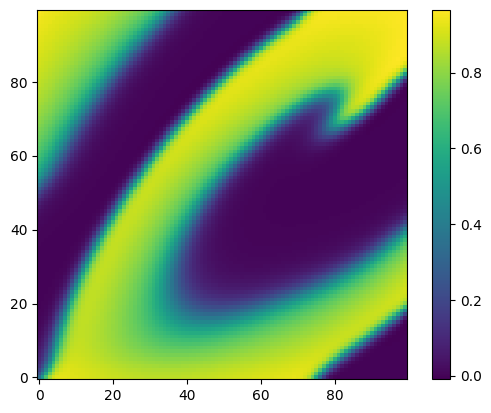

In [7]:
import matplotlib.pyplot as plt

import finitewave as fw
import numpy as np

# create a tissue of size 400x400 with cardiomycytes:
n = 100
alpha = np.pi / 4
tissue = fw.CardiacTissue([n, n], dr=0.25)
# tissue.mesh[0, 0] = 0
# tissue.mesh += (np.random.random(tissue.mesh.shape) < 0.1).astype(tissue.mesh.dtype)
# tissue.conductivity = (np.random.random(tissue.mesh.shape) < (1 - 0.3)).astype(np.float64)
tissue.fibers = np.zeros([n, n, 2])
tissue.fibers[:, :, 0] = np.cos(alpha)
tissue.fibers[:, :, 1] = np.sin(alpha)

# set up stimulation parameters:
stim_sequence = fw.StimSequence()
# stim_sequence.add_stim(fw.StimVoltageCoord(time=0, volt_value=1,
#                                            x_min=n//2 - 3, x_max=n//2 + 3,
#                                            y_min=n//2 - 3, y_max=n//2 + 3))

stim_sequence.add_stim(fw.StimVoltageCoord(time=0,
                                          volt_value=1,
                                          x_min=0, x_max=n,
                                          y_min=0, y_max=n//2))
stim_sequence.add_stim(fw.StimVoltageCoord(time=32,
                                          volt_value=1,
                                          x_min=0, x_max=n//2,
                                          y_min=0, y_max=n))

diffusion_model = fw.GridModel()
diffusion_model.stencil = fw.CellStencil()

# create model object and set up parameters:
simulation = fw.CardiacSimulation()
simulation.dt = 0.01
simulation.t_max = 100
simulation.cardiac_model = fw.AlievPanfilov()
simulation.cardiac_tissue = tissue
simulation.stim_sequence = stim_sequence
simulation.diffusion_model = diffusion_model

# run the model:
simulation.run()

# u_symmetric = simulation.cardiac_model.u.copy()

u = simulation.cardiac_model.u.copy()
u = np.ma.masked_where(u == 0, u)
%matplotlib inline
plt.figure()
plt.imshow(u, origin="lower")
plt.colorbar()
plt.show()

In [14]:
%matplotlib qt

fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
axs[0].imshow(u, origin="lower")
axs[0].set_title("Voltage")
axs[1].imshow(tissue.conductivity, origin="lower")
axs[1].set_title("Conductivity")
plt.tight_layout()
plt.show()

[False  True  True  True  True  True  True  True  True]


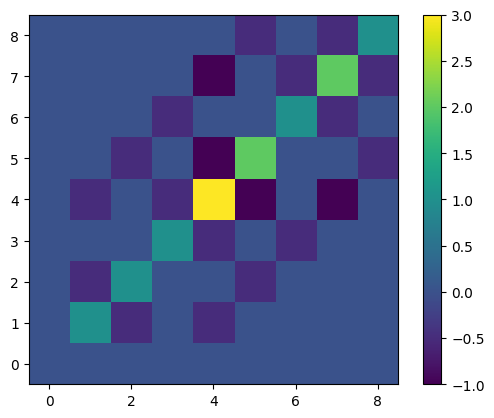

In [17]:
import numpy as np
import finitewave as fw
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix


n = 3
mesh = np.ones([n, n], dtype=np.float64)
cond = np.ones([n, n], dtype=np.float64)
cond[0, 0] = 0

diff = np.zeros([n, n, 2, 2], dtype=np.float64)
diff[:, :, 0, 0] = 1.
diff[:, :, 1, 1] = 1.

diff[:, :, 0, 0] *= cond
diff[:, :, 1, 1] *= cond

ijk = np.where(mesh > 0)

print(np.any(diff[*ijk, :, :] > 0, axis=(1, 2)))

indexes = np.arange(n * n)

stencil = fw.CellStencil()

w = stencil.compute_diffusion_weights(mesh, diff, 1, indexes)

K = csr_matrix((w[2], (w[0], w[1])), shape=(n * n, n * n))

%matplotlib inline
plt.imshow(K.toarray(), origin="lower")
plt.colorbar()
plt.show()

In [ ]:
import numpy as np
import finitewave as fw
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix


n = 3
mesh = np.ones([n, n, n], dtype=np.float64)
cond = np.ones([n, n, n], dtype=np.float64)
cond[0, 0, 0] = 0

diff = np.zeros([n, n, n, 3, 3], dtype=np.float64)
diff[:, :, :, 0, 0] = 1.
diff[:, :, :, 1, 1] = 1.
diff[:, :, :, 2, 2] = 1.

diff[:, :, 0, 0] *= cond
diff[:, :, 1, 1] *= cond
diff[:, :, 2, 2] *= cond

ijk = np.where(mesh > 0)

indexes = np.arange(n * n * n)

stencil = fw.CellStencil()

w = stencil.compute_diffusion_weights(mesh, diff, 1, indexes)

K = csr_matrix((w[2], (w[0], w[1])), shape=(n * n * n, n * n * n))

%matplotlib qt
plt.imshow(K.toarray(), origin="lower")
plt.colorbar()
plt.show()

Running AlievPanfilov on [100, 100, 10] Grid: 100%|█████████▉| 9999/10000 [00:03<00:00, 3154.97it/s]


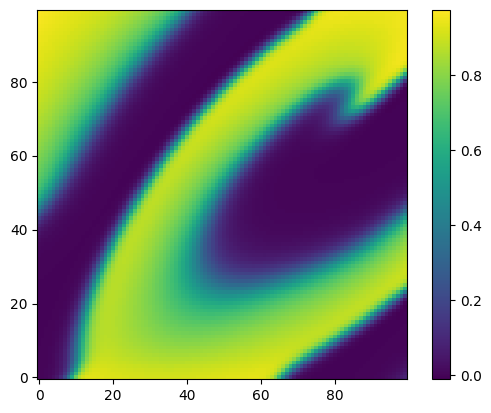

In [8]:
import matplotlib.pyplot as plt

import finitewave as fw
import numpy as np

# create a tissue of size 400x400 with cardiomycytes:
n = 100
m = 10
alpha = np.pi / 4
tissue = fw.CardiacTissue([n, n, m], dr=0.25)
# tissue.mesh[0, 0] = 0
# tissue.mesh += (np.random.random(tissue.mesh.shape) < 0.1).astype(tissue.mesh.dtype)
# tissue.conductivity = (np.random.random(tissue.mesh.shape) < (1 - 0.3)).astype(np.float64)
tissue.fibers = np.zeros([n, n, m, 3])
tissue.fibers[:, :, :, 0] = np.cos(alpha)
tissue.fibers[:, :, :, 1] = np.sin(alpha)
tissue.fibers[:, :, :, 2] = 0

# set up stimulation parameters:
stim_sequence = fw.StimSequence()
# stim_sequence.add_stim(fw.StimVoltageCoord(time=0, volt_value=1,
#                                            x_min=n//2 - 3, x_max=n//2 + 3,
#                                            y_min=n//2 - 3, y_max=n//2 + 3))

stim_sequence.add_stim(fw.StimVoltageCoord(time=0,
                                          volt_value=1,
                                          x_min=0, x_max=n,
                                          y_min=0, y_max=n//2,
                                          z_min=0, z_max=m))
stim_sequence.add_stim(fw.StimVoltageCoord(time=32,
                                          volt_value=1,
                                          x_min=0, x_max=n//2,
                                          y_min=0, y_max=n,
                                          z_min=0, z_max=m))

diffusion_model = fw.GridModel()
diffusion_model.stencil = fw.CellStencil()

# create model object and set up parameters:
simulation = fw.CardiacSimulation()
simulation.dt = 0.01
simulation.t_max = 100
simulation.cardiac_model = fw.AlievPanfilov()
simulation.cardiac_tissue = tissue
simulation.stim_sequence = stim_sequence
simulation.diffusion_model = diffusion_model

# run the model:
simulation.run()

# u_symmetric = simulation.cardiac_model.u.copy()

u = simulation.cardiac_model.u.copy()
u = np.ma.masked_where(u == 0, u)
%matplotlib inline
plt.figure()
plt.imshow(u[:, :, m//2], origin="lower")
plt.colorbar()
plt.show()

In [66]:
import numpy as np


def foo(diffusion):
    junc_diffusion = np.zeros_like(diffusion)

    dim = diffusion.shape[-2]
    
    for d in range(dim):

        if diffusion.shape[d] < 2:
            continue
        
        index_left = [slice(None)] * (dim + 2)
        index_left[d] = slice(None, -1)
        index_left[dim] = d
        index_left = tuple(index_left)
        
        index_right = [slice(None)] * (dim + 2)
        index_right[d] = slice(1, None)
        index_right[dim] = d
        index_right = tuple(index_right)

        d_i = (diffusion[index_left] + diffusion[index_right]) / 2.0
        junc_diffusion[index_left] = d_i
    return junc_diffusion


D_3x3 = np.zeros((1, 2, 5, 3, 3), dtype=np.float64)
for i in range(3):
    D_3x3[..., i, i] = 1.

D_2x2 = np.zeros((1, 5, 2, 2), dtype=np.float64)
for i in range(2):
    D_2x2[..., i, i] = 1.

print(D_3x3.shape)
print(D_2x2.shape)

J_3x3 = foo(D_3x3)
J_2x2 = foo(D_2x2)

print(J_3x3.shape)
print(J_2x2)

# D_3x3[slice(None), slice(None), slice(None, -1), 2, slice(None)]


(1, 2, 5, 3, 3)
(1, 5, 2, 2)
(1, 2, 5, 3, 3)
[[[[0. 0.]
   [0. 1.]]

  [[0. 0.]
   [0. 1.]]

  [[0. 0.]
   [0. 1.]]

  [[0. 0.]
   [0. 1.]]

  [[0. 0.]
   [0. 0.]]]]
